Today's topics:
* aggregations: squeezing an array down to one number
* mean, median, min, max, variance, standard deviation (by hand first, then NumPy)

# What is the yield strength of a titanium alloy?

We've been treating properties as single numbers so far (the density of
copper, the radius of an atom).

Real materials aren't so tidy. Ask a metallurgist for the yield strength of
titanium and you'll get a range, not a number.

Let's look at real data. Salvador and coworkers (2022) went through about a
hundred papers and compiled the mechanical properties of 283 titanium alloys.

Run the cell below; you don't need to read its code.

([Salvador et al., *Scientific Data* 9, 188](https://doi.org/10.1038/s41597-022-01283-9), CC BY 4.0)

In [1]:
#@title Load the Ti-alloy dataset (click ▶ to run, data loading, not a learning objective) { display-mode: "form" }
import os

import numpy as np
import pandas as pd

_file = 'biomaterials_ti_alloys.csv'
_github = f'https://raw.githubusercontent.com/wfreinhart/matse219/main/datasets/{_file}'
_local = next(
    (p for p in (f'datasets/{_file}', f'../datasets/{_file}', f'../../datasets/{_file}',
                 f'../../../datasets/{_file}')
     if os.path.exists(p)),
    None,
)

try:
    _table = pd.read_csv(_local if _local else _github)
except Exception as e:
    raise RuntimeError(
        f"Could not load '{_file}'. If you are in Colab, check your internet "
        f"connection and that the file exists at {_github}"
    ) from e

_tension = _table[_table['test_mode'] == 'tension']

_ys = _tension.dropna(subset=['YS_MPa'])
alloy = _ys['eid'].to_numpy()
yield_strength = _ys['YS_MPa'].to_numpy()

_ym = _table.dropna(subset=['YM_GPa'])
alloy_modulus = _ym['eid'].to_numpy()
modulus = _ym['YM_GPa'].to_numpy()

uts = _tension['UTS_MPa'].dropna().to_numpy()
hardness_hv = _table['HV'].dropna().to_numpy()

print(f'Loaded {len(_table)} titanium alloys from {_file}')
print(f'  yield_strength: {len(yield_strength)} values (MPa, tensile tests only)')
print(f'  modulus:        {len(modulus)} values (GPa)')
print(f'  uts:            {len(uts)} values (MPa, tensile tests only)')
print(f'  hardness_hv:    {len(hardness_hv)} values (Vickers)')

Loaded 283 titanium alloys from biomaterials_ti_alloys.csv
  yield_strength: 195 values (MPa, tensile tests only)
  modulus:        237 values (GPa)
  uts:            169 values (MPa, tensile tests only)
  hardness_hv:    152 values (Vickers)


We'll start with the 195 alloys that have a yield strength from a tensile
test.

(The table also has compression tests, which give much higher numbers for the
same alloy, so we're leaving those out. Comparing like with like is rule one.)

In [2]:
print(yield_strength)

[ 782.   735.   672.  1011.   765.  1027.   348.   606.   625.   629.
  650.   537.   511.   441.   810.   782.   729.   682.   501.   780.
  553.  1038.   665.  1107.   932.   953.   754.7  600.   499.   566.
  533.   806.   897.   760.   800.   396.   441.   379.   373.   376.
  444.   257.   557.   213.   599.   432.   367.   501.   636.   731.
  823.   862.   972.  1062.  1152.   535.   588.   711.  1181.  1299.
 1421.  1553.  1399.  1068.   499.1  369.   406.   439.   530.   551.
  964.   480.   829.   804.   750.  1710.   740.   690.   955.  1065.
  203.   301.   575.   509.   200.   200.   170.   275.   380.   483.
 1023.   927.   980.  1046.  1077.  1033.   700.   380.   480.   650.
  289.   237.   216.   262.   554.   519.   481.   635.   456.   374.
  433.   376.   327.   411.   377.   395.   338.   303.   340.   314.
  714.   780.   561.   588.   632.   720.   613.   382.   389.   405.
  540.   662.   446.   791.   794.   775.   808.   550.   740.  1390.
  899.   947.   483.

All in MPa, some below 200 and some above 1500. The answer to our question is
in there somewhere, but we can't report all 195 numbers. What should we use
instead?

Squeezing an array down to one number is called an **aggregation**. Let's
build the common ones by hand first, then let NumPy do them in one call.

# Summing the values

The simplest aggregation is the sum. Python has a built-in `sum`, and NumPy
has `np.sum`. Let's try both:

In [3]:
import numpy as np

print(sum(yield_strength))
print(np.sum(yield_strength))

125802.79999999999
125802.8


Same answer, apart from the last digit (floating-point rounding, remember
L02?). We'll use `np.sum` from here on, since it's much faster on big arrays
and it takes `axis` from L04.

The sum by itself isn't very interesting. The total yield strength of 195
alloys is not a physical quantity! Divide by the count, though, and we get
one.

# Mean: the balance point

$$\bar{x} = \frac{1}{N}\sum_{i=1}^N x_i$$
Add everything up, divide by how many. Let's do it the long way once, so the
formula is more than notation (`len` gives us the count):

In [4]:
total = np.sum(yield_strength)
N = len(yield_strength)
mean_by_hand = total / N
print(f'N = {N}')
print(f'mean (by hand): {mean_by_hand:.1f} MPa')

N = 195
mean (by hand): 645.1 MPa


And the one-call version:

In [5]:
print(f'mean (np.mean): {np.mean(yield_strength):.1f} MPa')

mean (np.mean): 645.1 MPa


A useful picture: every value is a weight on a ruler, and the mean is where
the fulcrum goes to balance it.

Values far from the center have more leverage, and that will matter in a few
minutes.

# Minimum and maximum

Remember `np.min` and `np.max` from L02? The lowest and highest yield
strengths in the table:

In [6]:
print(f'min: {np.min(yield_strength):.0f} MPa')
print(f'max: {np.max(yield_strength):.0f} MPa')

min: 170 MPa
max: 1710 MPa


A factor of ten! So which alloy is that 1710?

`np.argmax` gives us the *position* of the maximum rather than its value, and
since the `alloy` array is lined up with `yield_strength`, the same position
picks out the name:

In [7]:
strongest = np.argmax(yield_strength)
print(strongest)
print(alloy[strongest])
print(yield_strength[strongest])

75
TiZr-5Al
1710.0


A Ti-Zr-Al alloy, solution treated and water quenched.

That is the highest tensile yield strength anyone reported in this table,
which is not quite the same as the strongest titanium alloy that exists.

# Median: the middle value

The mean is one idea of "center." Another is the middle of the sorted data,
with as many values below as above. Let's sort and walk to the middle:

In [8]:
sorted_ys = np.sort(yield_strength)
print(sorted_ys[:10])
print(sorted_ys[-10:])

[170. 200. 200. 202. 203. 213. 216. 237. 249. 257.]
[1132. 1152. 1181. 1210. 1299. 1390. 1399. 1421. 1553. 1710.]


195 is odd, so there's a single middle element at position 97 (remember,
positions run from 0 to 194):

In [9]:
median_by_hand = sorted_ys[97]
print(f'median (by hand): {median_by_hand:.1f} MPa')
print(f'median (np.median): {np.median(yield_strength):.1f} MPa')

median (by hand): 588.0 MPa
median (np.median): 588.0 MPa


*Tutorial: even N.* With an even count there are two middle elements, and the
median is their average. For `N = 6` that's positions 2 and 3; for `N = 152`
it's 75 and 76.

`np.median` handles both cases for us. When we do it by hand, we check whether
`N` is odd or even before picking the index.

Mean 645 MPa, median 588 MPa. Why do they differ? The gap is our first clue
about the shape of the distribution, so let's check it with a histogram:

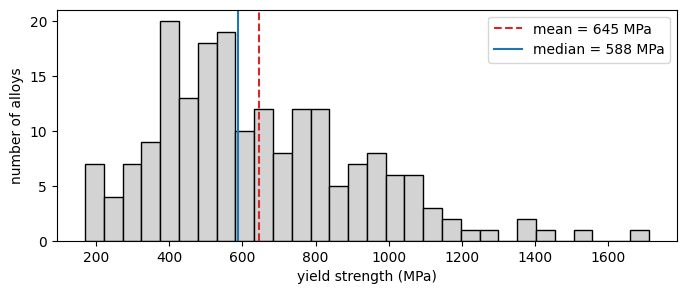

In [10]:
#@title Visualization: histogram of yield strength with mean and median marked (click ▶ to run) { display-mode: "form" }
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(yield_strength, bins=30, color='lightgray', edgecolor='black')
ax.axvline(np.mean(yield_strength), color='C3', linestyle='--', label=f'mean = {np.mean(yield_strength):.0f} MPa')
ax.axvline(np.median(yield_strength), color='C0', linestyle='-', label=f'median = {np.median(yield_strength):.0f} MPa')
ax.set_xlabel('yield strength (MPa)')
ax.set_ylabel('number of alloys')
ax.legend()
plt.show()

Most alloys sit between 300 and 900 MPa, with a long tail of high-strength
alloys off to the right.

Those high values have a lot of leverage on our balance point, so the mean
gets pulled toward the tail.

The median depends on order, not on distance from the center. Changing that
1710 to 3000 would leave it exactly where it is.

So why are the mean and median different? The long tail. A few unusually high
values pull the mean to the right, while the median barely changes when they
move.

The gap between the two numbers suggested skew, and the histogram supports it.

We say the median is more **robust**. That doesn't make it the better center
every time, since the mean is the one that counts every value, tail included.

### [Check your understanding]

The same table has ultimate tensile strength for 169 alloys, in `uts`, and
Vickers hardness for 152 alloys, in `hardness_hv`.

1. Print the number of values, the mean, and the median of `uts`
2. Which is larger, the mean or the median? What shape would you *guess* from
   that, and what would you look at to check the guess?
3. Print the min and the max of `uts`
4. `hardness_hv` has an even number of values. Sort it, compute the median by
   hand from the two middle positions, and check against `np.median`

*Optional challenge*

5. The mean is always between the min and the max. Is the median? Check with
   `uts`, then decide whether it has to be true in general.

# Other aggregation functions

NumPy has many more of these (don't memorize the table!). They all follow the
same pattern as `np.mean`, and most have a `nan`-safe twin for missing values.

| Function | NaN-safe version | Description | Today |
|---|---|---|---|
| `np.sum` | `np.nansum` | Sum of elements | yes |
| `np.prod` | `np.nanprod` | Product of elements | |
| `np.mean` | `np.nanmean` | Mean of elements | yes |
| `np.std` | `np.nanstd` | Standard deviation | yes |
| `np.var` | `np.nanvar` | Variance | yes |
| `np.min` | `np.nanmin` | Minimum value | yes |
| `np.max` | `np.nanmax` | Maximum value | yes |
| `np.argmin` | `np.nanargmin` | Position of the minimum | yes |
| `np.argmax` | `np.nanargmax` | Position of the maximum | yes |
| `np.median` | `np.nanmedian` | Median | yes |
| `np.percentile` | `np.nanpercentile` | Rank-based statistics | |
| `np.any` | | Is any element true? | |
| `np.all` | | Are all elements true? | |

(Adapted from VanderPlas, *Python Data Science Handbook*, section 2.4.)
They also take `axis`. Remember `np.max(table, axis=0)` from L04? Same idea
here, and the axis we name is the one that disappears:

In [11]:
grid = np.array([[1, 2, 3],
                 [4, 5, 6]])
print(np.mean(grid))
print(np.mean(grid, axis=0))
print(np.mean(grid, axis=1))

3.5
[2.5 3.5 4.5]
[2. 5.]


One number, then three column means, then two row means. HW2 asks for exactly
this on a hardness map, so it's worth a second look.

# Variance: how spread out?

Two centers and two extremes, and still no number for how *wide* the
distribution is. How far is each alloy from the mean? Let's subtract and see.

In [12]:
mu = np.mean(yield_strength)
deviations = yield_strength - mu
print(deviations[:10])

[ 136.8574359   89.8574359   26.8574359  365.8574359  119.8574359
  381.8574359 -297.1425641  -39.1425641  -20.1425641  -16.1425641]


Positive above the mean, negative below. The obvious next move is to average
them, so let's try:

In [13]:
print(f'mean deviation: {np.mean(deviations):.6f}')

mean deviation: -0.000000


Zero! (To the precision of the arithmetic, anyway.) This is not a coincidence
and it is not a property of titanium.

It happens for every dataset, because "balance point" means exactly that: the
positive and negative deviations cancel.

So we need a measure that doesn't cancel. The **variance** averages squared
deviations, which are always positive (and weight big deviations more
heavily). Square each one, then average:

$$\sigma^2 = \frac{1}{N}\sum_{i=1}^N (x_i - \bar{x})^2$$

In [14]:
squared_deviations = deviations ** 2
variance_by_hand = np.sum(squared_deviations) / N
print(f'variance (by hand): {variance_by_hand:.0f}')

variance (by hand): 80521


And `np.var` does the same in one call:

In [15]:
print(f'variance (np.var): {np.var(yield_strength):.0f}')

variance (np.var): 80521


*Tutorial: `ddof`.* `np.var` divides by $N$, and your statistics textbook
probably divides by $N - 1$. Dividing by $N$ describes the values we have.

Dividing by $N - 1$ is the usual choice when the values are a random sample
from some larger population and we want an unbiased estimate of *its*
variance.

NumPy exposes the choice as `ddof` ("delta degrees of freedom"):

In [16]:
print(f'variance (ddof=0): {np.var(yield_strength, ddof=0):.0f}')
print(f'variance (ddof=1): {np.var(yield_strength, ddof=1):.0f}')

variance (ddof=0): 80521
variance (ddof=1): 80936


At $N = 195$ the two differ by half a percent, so it hardly matters here. At
$N = 5$ the `ddof=1` variance is 25% larger, and it matters a lot.

We're describing a table today, so `ddof=0`, and that's the convention HW2
uses. Whichever you pick, say which one when you report the number.

# Standard deviation

Our variance is about 80,000. In what units? We squared MPa, so
$\mathrm{MPa}^2$, which isn't very intuitive. The square root gets us back to
MPa:

$$\sigma = \sqrt{\sigma^2}$$

In [17]:
std_by_hand = np.sqrt(variance_by_hand)
print(f'standard deviation (by hand): {std_by_hand:.1f} MPa')
print(f'standard deviation (np.std):  {np.std(yield_strength):.1f} MPa')

standard deviation (by hand): 283.8 MPa
standard deviation (np.std):  283.8 MPa


So across these 195 alloys, the mean is 645 MPa and the standard deviation is
284 MPa.

Be careful with that 284, though: it describes the spread of this table, not
the uncertainty in the mean, and it isn't a spec.

It's also a good reminder that "titanium alloy" covers a very broad range of
materials!

Picking the member that suits the application matters more than knowing the
family average. (`np.std` takes `ddof` too, same choice.)

### [Check your understanding]

Let's do variance and standard deviation by hand on something small enough to
see every step: the first five yield strengths, `small = yield_strength[:5]`.
No `np.var` or `np.std` until step 5.

1. Mean
2. Deviations from the mean
3. Square them, then average. That's the variance
4. `np.sqrt` of the variance. That's the standard deviation
5. Check both against `np.var(small)` and `np.std(small)`

*Optional challenge*

6. Repeat step 5 with `ddof=1`. By what percentage is the `ddof=1` variance
   larger at $N = 5$? And the standard deviation?

# Example: stiffness for a bone implant

Let's run everything we built on a different column and a real design
question.

Cortical bone has a Young's modulus around 10 to 30 GPa, depending on
direction and site (20 GPa is a handy comparison value).

An implant much stiffer than the bone around it carries more than its share of
the load, the bone carries less, and under-loaded bone resorbs.

We call this **stress shielding**. It's one reason engineers pick titanium

(about 110 GPa for the workhorse Ti-6Al-4V) for hip stems over stainless steel
(about 200 GPa).

Lower still would help, as long as strength and fatigue life hold up.

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/4/47/Hip_joint_replacement%2C_United_States%2C_1998_Wellcome_L0060175.jpg/500px-Hip_joint_replacement%2C_United_States%2C_1998_Wellcome_L0060175.jpg" alt="Titanium alloy hip joint replacement, United States, 1998" height=220/>

(Titanium-alloy hip prosthesis, [Wellcome Collection via Wikimedia Commons](https://commons.wikimedia.org/wiki/File:Hip_joint_replacement,_United_States,_1998_Wellcome_L0060175.jpg), [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/))

The table has Young's modulus for 237 alloys, in `modulus`, with the matching
names in `alloy_modulus`:

In [18]:
print(f'N:      {len(modulus)}')
print(f'mean:   {np.mean(modulus):.1f} GPa')
print(f'median: {np.median(modulus):.1f} GPa')
print(f'std:    {np.std(modulus):.1f} GPa')
print(f'min:    {np.min(modulus):.1f} GPa')
print(f'max:    {np.max(modulus):.1f} GPa')

N:      237
mean:   81.9 GPa
median: 78.0 GPa
std:    21.7 GPa
min:    45.0 GPa
max:    157.0 GPa


The typical alloy here is already well below Ti-6Al-4V, but be careful: this
table is heavy on beta-titanium alloys, many of them studied for implants in
the first place, so that's a selection effect rather than a fact about
titanium.

The minimum, 45 GPa, is closer to bone than to steel. Which alloy?

In [19]:
most_compliant = np.argmin(modulus)
print(alloy_modulus[most_compliant])
print(f'{modulus[most_compliant]:.0f} GPa')

Ti-30Nb-1Mo-4Sn
45 GPa


The minimum belongs to a Ti-Nb-Mo-Sn alloy. Now we have several different ways
to describe this column, and `argmin` returns the one alloy worth reading
about first.

## An automated summary

Six separate calls is fine for six numbers, but SciPy can report most of them
at once.

You don't need to learn this (it won't be on an assignment), it's just worth
knowing it exists:

In [20]:
#@title Optional tool glimpse: several statistics in one call with scipy.stats.describe (click ▶ to run) { display-mode: "form" }
from scipy.stats import describe

print(describe(modulus, ddof=0))

DescribeResult(nobs=np.int64(237), minmax=(np.float64(45.0), np.float64(157.0)), mean=np.float64(81.94632911392405), variance=np.float64(469.746918592106), skewness=np.float64(0.8776955294453123), kurtosis=np.float64(0.6980920486964548))


`nobs`, `minmax`, `mean`, and `variance` all match our cell above. We had to
pass `ddof=0`, though, because this function divides by $N - 1$ by default.

Even with the arithmetic automated, the convention is still our call.

# One number is never enough

So what is the yield strength of a titanium alloy? No single number describes
it well. For these 195 tensile records we'd report the center

(median 588 MPa, mean 645 MPa), the spread (284 MPa), and the range (170 to
1710 MPa). Each aggregation is one fact about the data, with everything else
left out. Report a center without a spread and "titanium alloy" sounds like
one material. One last caveat, and it applies to every compiled dataset you'll
ever meet.

These 283 records are what a hundred research groups chose to make, test, and
publish, several rows share a paper, and we ignored every error bar. We're
describing this table, not every titanium alloy that could be made.

## Further reading

- [VanderPlas: Aggregations (min, max, and everything in between)](https://jak
evdp.github.io/PythonDataScienceHandbook/02.04-computation-on-arrays-
aggregates.html) - [McKinney: NumPy
basics](https://wesmckinney.com/book/numpy-basics) (descriptive statistics
section) - [Salvador et al., *Scientific Data* 9, 188

(2022)](https://doi.org/10.1038/s41597-022-01283-9), the source of today's
data